# Part 3.2 Final Shape-Medium Submission

Notebook này dựng final line từ baseline nội bộ rồi chỉnh daily shape theo bucket horizon.


In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np

ROOT = Path('/home/lducc/code/datathon/datathon-2026-round-1')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.data import load_dataframes
from models.baseline_internal_bottomup import build_internal_bottomup_baseline, _monthly_components, _seasonal_trend_forecast, _daily_shape_profile
from models.final_shape_medium import build_final_shape_medium_submission
from scripts.run_part2_pipeline import configure_style, plot_final_shape_medium_monthly_revenue, plot_final_shape_medium_correction
from models.data import build_daily_frame

configure_style()
data = load_dataframes()
daily = build_daily_frame(data)


In [2]:
outputs = build_final_shape_medium_submission()
pd.read_csv(outputs['final_submission']).head()


,Date,Revenue,COGS
0,2023-01-01,5070013.23,4472299.21
1,2023-01-02,2426270.68,2043814.59
2,2023-01-03,1766495.12,1468179.76
3,2023-01-04,2339078.23,1925606.49
4,2023-01-05,2326805.10,1924189.32


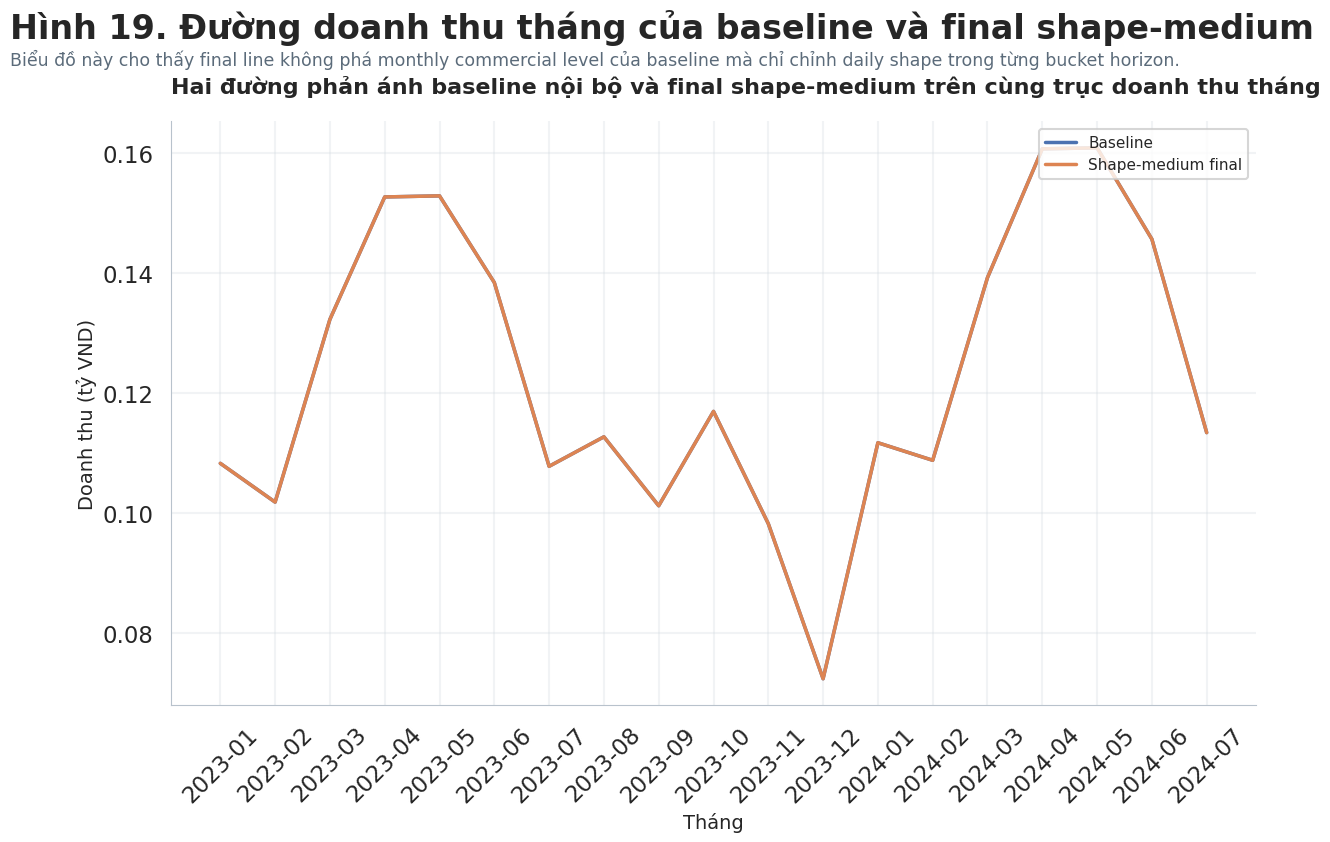

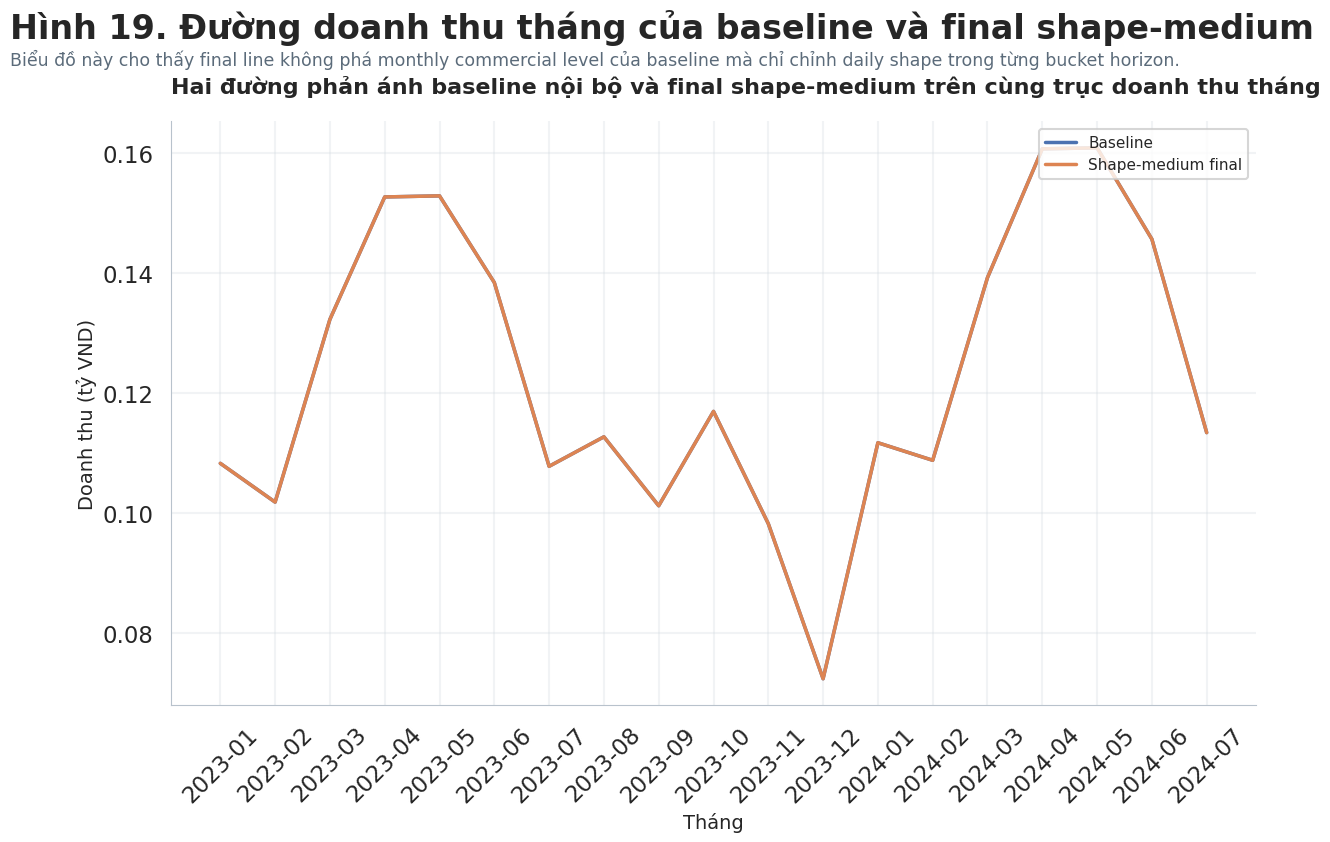

In [3]:
fig = plot_final_shape_medium_monthly_revenue()
fig


**Diễn giải**

Final line giữ monthly commercial level của baseline, chỉ điều chỉnh shape trong tháng. Đây là cách cân bằng giữa interpretability và khả năng thích ứng với pattern daily gần hơn.


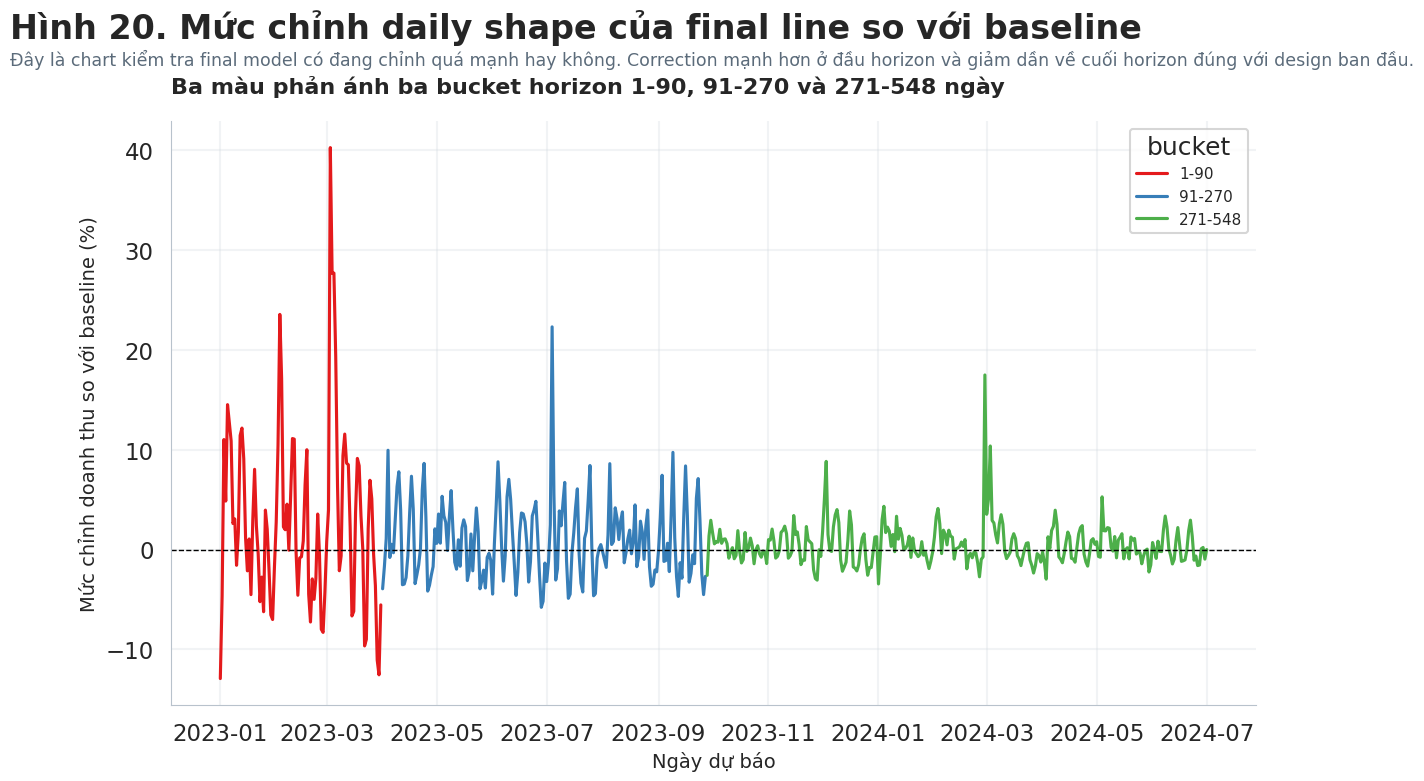

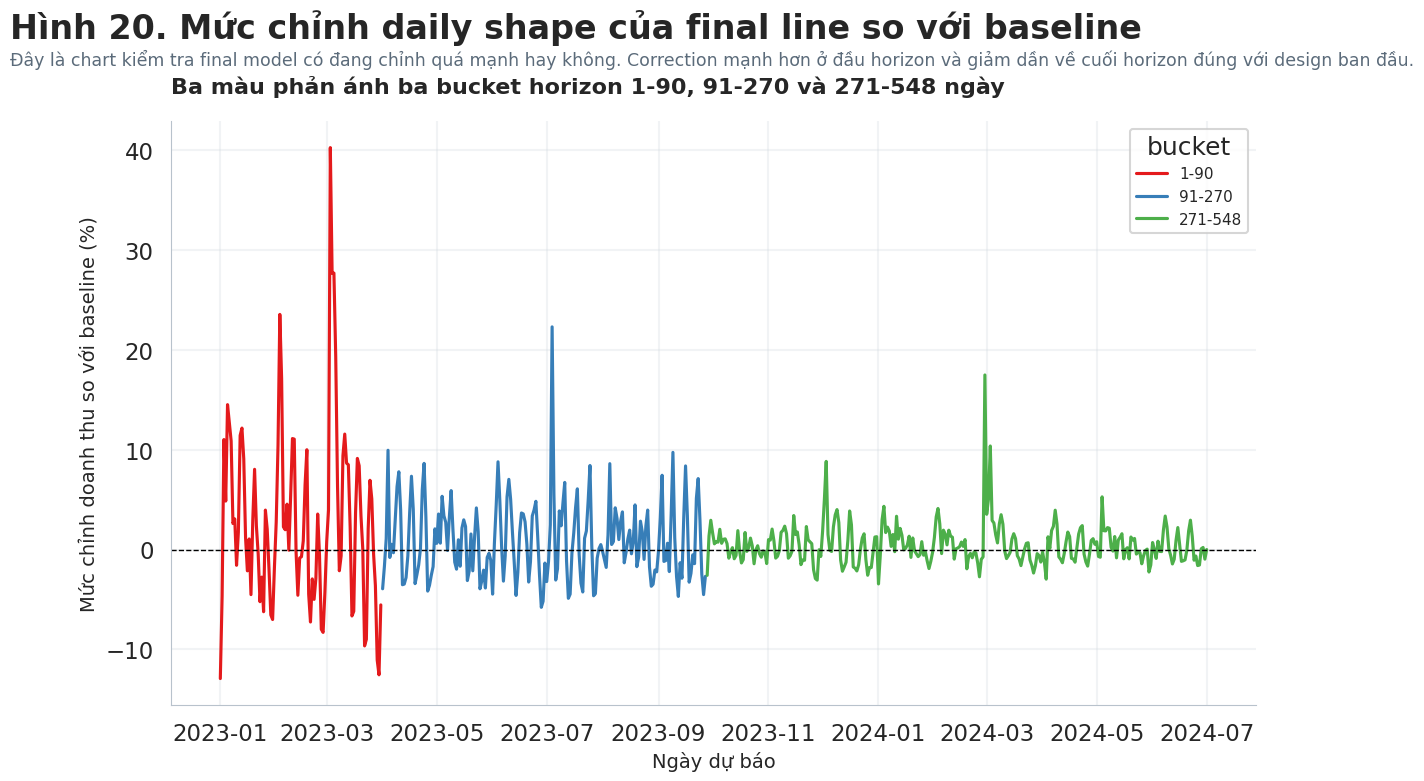

In [4]:
fig = plot_final_shape_medium_correction()
fig


**Diễn giải**

Correction mạnh hơn ở đầu horizon và giảm dần về cuối horizon. Đó là đúng với design của shape-medium: gần thì cho phép linh hoạt hơn, xa thì bám baseline chặt hơn.
